# BASE CASE

⚡ Cache valid! Loading 5m base data from disk...
Data Loaded. Shape: (298081, 244)

=== RUNNING BASE CASE ONLY ===

[START] BASE CASE -> L-Window: Medium_8h | Y-Interval: 5m
[Medium_8h_5m] -> 2025-11-01 00:00:00 | CumPnL: 13.45 | Bench: -58.82   
Saved Medium_8h_5m to disk.

BASE CASE RESULTS COMPARISON (STRATEGY VS BENCHMARK)
              Strat Ret  Bench Ret  Strat DD  Bench DD  Strat Sharpe  Bench Sharpe  Strat Sortino  Bench Sortino
Test Case                                                                                                       
Medium_8h_5m      67.24    -294.08     -6.53   -119.08          2.93         -1.38           1.17           -1.3


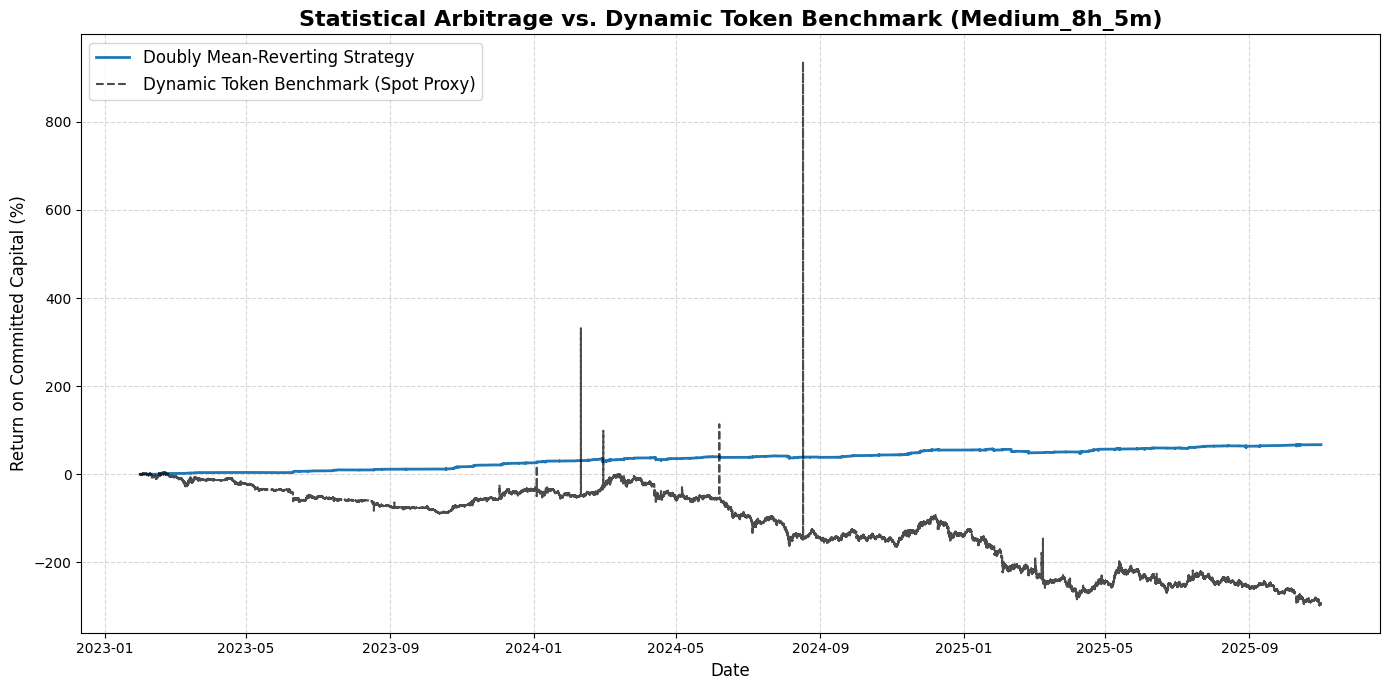

In [ ]:
# %%
# ==============================================================================
# MASTER THESIS: CRYPTO PAIRS TRADING - BASE CASE RESULTS
# ==============================================================================

import os
import glob
import json
import warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Jupyter inline plotting
%matplotlib inline
warnings.filterwarnings('ignore')

# ==========================================
# 1. CONFIGURATION (BASE CASE ONLY)
# ==========================================
class Config:
    # --- PATHS ---
    DATA_PATH = "D:\\MASTER THESIS DATA\\bitmex\\processed_5m_bidask\\"
    FUNDING_PATH = "D:\\MASTER THESIS DATA\\bitmex\\funding_rates\\"
    OUTPUT_DIR = "D:\\MASTER THESIS DATA\\results\\"
    CACHE_DIR = os.path.join(OUTPUT_DIR, "data_cache")
    RESULTS_DIR = os.path.join(OUTPUT_DIR, "run_results") 
    
    # --- DATES ---
    START_DATE = "2023-01-01"
    END_DATE = "2025-11-01"
    
    # --- STRATEGY PARAMS ---
    CORR_THRESHOLD = 0.90    
    MAX_PAIRS = 10           
    
    # --- COSTS & LIMITS ---
    TC_BPS = 5               # 5 bps per leg (0.05%)
    MAX_SPREAD_PCT = 0.05    # 5% max spread filter for entries
    COMMITTED_CAPITAL = 20.0 # 10 pairs * 2 legs * 1.0 unit
    
    # --- BASE CASE DEFINITION (Chapter 4 Results) ---
    BASE_Y_INTERVAL = "5m"
    BASE_CASE = {
        "name": "Medium_8h", 
        "l_freq": "8h",  
        "window_l": 30,  
        "window_y": 7
    }
    
    # --- DATA ---
    FFILL_LIMIT = 288        # Forward fill up to 24h

# Ensure directories exist
for d in [Config.OUTPUT_DIR, Config.CACHE_DIR, Config.RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# %%
# ==========================================
# 2. DATA HANDLERS (WITH CACHING & RESAMPLING)
# ==========================================
class FastDataHandler:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df_mid = self.df_bid = self.df_ask = None
        self.meta_file = os.path.join(Config.CACHE_DIR, "meta.json")

    def _is_cache_valid(self):
        if not os.path.exists(self.meta_file): return False
        try:
            with open(self.meta_file, "r") as f: meta = json.load(f)
            return (meta.get("START_DATE") == Config.START_DATE and
                    meta.get("END_DATE") == Config.END_DATE)
        except: return False

    def load_data(self):
        if self._is_cache_valid():
            print(f"⚡ Cache valid! Loading 5m base data from disk...")
            self.df_mid = pl.read_parquet(os.path.join(Config.CACHE_DIR, "mid.parquet"))
            self.df_bid = pl.read_parquet(os.path.join(Config.CACHE_DIR, "bid.parquet"))
            self.df_ask = pl.read_parquet(os.path.join(Config.CACHE_DIR, "ask.parquet"))
            print(f"Data Loaded. Shape: {self.df_mid.shape}")
            return

        print(f"Processing raw data from {self.folder_path}...")
        all_files =[f for f in glob.glob(os.path.join(self.folder_path, "**", "*.parquet"), recursive=True) if "data_cache" not in f]
        
        q = pl.scan_parquet(all_files).with_columns(pl.col("timestamp").cast(pl.Datetime))
        q = q.with_columns([
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("mid_price")).otherwise(None).alias("mid_price"),
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("bid_price")).otherwise(None).alias("bid_price"),
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("ask_price")).otherwise(None).alias("ask_price")
        ])
        
        df_long = q.collect()
        s_dt, e_dt = datetime.strptime(Config.START_DATE, "%Y-%m-%d"), datetime.strptime(Config.END_DATE, "%Y-%m-%d")
        df_long = df_long.filter((pl.col("timestamp") >= s_dt) & (pl.col("timestamp") <= e_dt))
        
        print("Pivoting data matrices...")
        self.df_mid = df_long.pivot(index="timestamp", on="symbol", values="mid_price", aggregate_function="last").sort("timestamp")
        self.df_bid = df_long.pivot(index="timestamp", on="symbol", values="bid_price", aggregate_function="last").sort("timestamp")
        self.df_ask = df_long.pivot(index="timestamp", on="symbol", values="ask_price", aggregate_function="last").sort("timestamp")
        
        grid = pl.datetime_range(self.df_mid["timestamp"].min(), self.df_mid["timestamp"].max(), interval="5m", eager=True).alias("timestamp").to_frame()
        grid = grid.with_columns(pl.col("timestamp").cast(self.df_mid["timestamp"].dtype))
        
        def align(df):
            return grid.join(df, on="timestamp", how="left").with_columns(pl.all().forward_fill(limit=Config.FFILL_LIMIT))

        self.df_mid, self.df_bid, self.df_ask = align(self.df_mid), align(self.df_bid), align(self.df_ask)
        
        self.df_mid.write_parquet(os.path.join(Config.CACHE_DIR, "mid.parquet"))
        self.df_bid.write_parquet(os.path.join(Config.CACHE_DIR, "bid.parquet"))
        self.df_ask.write_parquet(os.path.join(Config.CACHE_DIR, "ask.parquet"))
        
        with open(self.meta_file, "w") as f:
            json.dump({"START_DATE": Config.START_DATE, "END_DATE": Config.END_DATE}, f)

    def get_resampled_slices(self, start, end, interval="5m"):
        mask = (self.df_mid["timestamp"] >= start) & (self.df_mid["timestamp"] <= end)
        mid = self.df_mid.filter(mask)
        bid = self.df_bid.filter(mask)
        ask = self.df_ask.filter(mask)
        
        if interval != "5m":
            mid = mid.set_sorted("timestamp").group_by_dynamic("timestamp", every=interval).agg(pl.exclude("timestamp").last())
            bid = bid.set_sorted("timestamp").group_by_dynamic("timestamp", every=interval).agg(pl.exclude("timestamp").last())
            ask = ask.set_sorted("timestamp").group_by_dynamic("timestamp", every=interval).agg(pl.exclude("timestamp").last())
            
        return mid, bid, ask

class FundingHandler:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df_funding = None
        
    def load_rates(self):
        try:
            q = pl.scan_csv(os.path.join(self.folder_path, "*.csv"))
            self.df_funding = (
                q.with_columns([pl.col("timestamp").str.replace("T", " ").str.replace("Z", "").str.to_datetime(strict=False).dt.replace_time_zone(None)])
                .drop_nulls(subset=["timestamp"]).select(["timestamp", "symbol", "fundingRate"])
                .collect().pivot(index="timestamp", on="symbol", values="fundingRate", aggregate_function="last").sort("timestamp")
            )
        except:
            print("Funding Load Failed.")
        
    def get_rates_slice(self, start, end):
        if self.df_funding is None: return None
        return self.df_funding.filter((pl.col("timestamp") >= start) & (pl.col("timestamp") <= end))

# %%
# ==========================================
# 3. MATH & ENGINE
# ==========================================
class OUCalibrator:
    @staticmethod
    def fit(spread, dt=1.0):
        if np.isnan(spread).any() or len(spread) < 15: return {'success': False}
        x, y = spread[:-1], spread[1:]
        denom = (len(spread)-1) * np.sum(x*x) - np.sum(x)**2
        if denom == 0: return {'success': False}
        
        b = ((len(spread)-1) * np.sum(x*y) - np.sum(x) * np.sum(y)) / denom
        a = (np.sum(y) - b * np.sum(x)) / (len(spread)-1)
        
        if b >= 0.999 or b <= 0.0: return {'success': False}
        
        theta = -np.log(b) / dt
        sigma = np.std(y - (a + b * x)) * np.sqrt((2 * theta) / (1 - b**2))
        return {'theta': theta, 'sigma': sigma, 'success': True}

class StrategyEngine:
    def __init__(self, dh, fh, params, y_interval):
        self.dh, self.fh = dh, fh
        self.p = params
        self.y_interval = y_interval
        
        self.y_mins = int(y_interval.replace("m", ""))
        self.dt_Y = self.y_mins / (24 * 60)
        self.dt_L = int(self.p['l_freq'].replace("h", "")) / 24.0
        
        self.equity_curve = []
        self.rq3_logs =[]

    def get_symbol_root(self, symbol):
        for base in['USDT', 'USDC', 'USD', 'EUR', 'BTC', 'ETH']:
            if symbol.endswith(base): return symbol[:-len(base)]
        return symbol

    def run(self):
        print(f"\n[START] BASE CASE -> L-Window: {self.p['name']} | Y-Interval: {self.y_interval}")
        df_L_agg = self.dh.df_mid.set_sorted("timestamp").group_by_dynamic("timestamp", every=self.p['l_freq']).agg(pl.exclude("timestamp").last())
        trend_dates = df_L_agg["timestamp"].to_list()
        
        # Align start time to wait out the initial calibration window
        start_idx = next(i for i, d in enumerate(trend_dates) if d >= trend_dates[0] + timedelta(days=self.p['window_l']))
        
        cumulative_pnl = 0.0
        cumulative_benchmark_pnl = 0.0
        all_syms =[c for c in self.dh.df_mid.columns if c != "timestamp"]
        
        for i in range(start_idx, len(trend_dates)-1):
            curr_t, next_t = trend_dates[i], trend_dates[i+1]
            
            df_L_hist = df_L_agg.filter((pl.col("timestamp") >= curr_t - timedelta(days=self.p['window_l'])) & (pl.col("timestamp") <= curr_t))
            df_Y_hist, _, _ = self.dh.get_resampled_slices(curr_t - timedelta(days=self.p['window_y']), curr_t, self.y_interval)
            df_t_mid, df_t_bid, df_t_ask = self.dh.get_resampled_slices(curr_t, next_t, self.y_interval)
            
            if df_t_mid.height < 5: continue

            valid_syms =[s for s in all_syms if df_Y_hist[s].null_count() == 0]
            if len(valid_syms) < 2: continue
            
            corr_mat = df_Y_hist.select(valid_syms).corr().to_numpy()
            cands =[]
            
            for r in range(len(valid_syms)):
                for c in range(r+1, len(valid_syms)):
                    sym_a, sym_b = valid_syms[r], valid_syms[c]
                    if self.get_symbol_root(sym_a) == self.get_symbol_root(sym_b) or corr_mat[r,c] < Config.CORR_THRESHOLD: continue
                    
                    l_vals = np.log(df_L_hist[sym_a].to_numpy()) - np.log(df_L_hist[sym_b].to_numpy())
                    pL = OUCalibrator.fit(l_vals, dt=self.dt_L)
                    if not pL['success']: continue
                    
                    y_vals = np.log(df_Y_hist[sym_a].to_numpy()) - np.log(df_Y_hist[sym_b].to_numpy())
                    pY = OUCalibrator.fit(y_vals, dt=self.dt_Y) 
                    if not pY['success']: continue
                    
                    var_L = (pL['sigma']**2 / (2 * pL['theta'])) * (1 - np.exp(-2 * pL['theta'] * self.dt_L))
                    var_Y = (pY['sigma']**2 / (2 * pY['theta'])) * (1 - np.exp(-2 * pY['theta'] * self.dt_Y))
                    
                    cands.append({
                        'pair': (sym_a, sym_b),
                        'score': var_Y / (var_L + 1e-9),
                        'var_y': var_Y,
                        'var_l': var_L,
                        'target': (l_vals[-1] + l_vals[-2]) / 2.0,
                        'eps': np.percentile(np.abs(np.diff(l_vals)), 98)
                    })
            
            cands.sort(key=lambda x: x['score'], reverse=True)
            final_selection, active_roots =[], set()
            
            for cand in cands:
                if len(final_selection) >= Config.MAX_PAIRS: break
                ra, rb = self.get_symbol_root(cand['pair'][0]), self.get_symbol_root(cand['pair'][1])
                if ra in active_roots or rb in active_roots: continue
                active_roots.add(ra); active_roots.add(rb)
                final_selection.append(cand)
            
            if not final_selection: continue
            
            session_pnl_path, session_bench_path = self.trade_session(pd.DataFrame(final_selection), df_t_mid, df_t_bid, df_t_ask, curr_t, next_t)
            
            ts_array = df_t_mid["timestamp"].to_numpy()
            for t_idx in range(len(ts_array)):
                self.equity_curve.append({
                    'time': ts_array[t_idx],
                    'pnl': cumulative_pnl + session_pnl_path[t_idx],
                    'benchmark_pnl': cumulative_benchmark_pnl + session_bench_path[t_idx]
                })
                
            cumulative_pnl += session_pnl_path[-1]
            cumulative_benchmark_pnl += session_bench_path[-1]
            print(f"[{self.p['name']}_{self.y_interval}] -> {next_t} | CumPnL: {cumulative_pnl:.2f} | Bench: {cumulative_benchmark_pnl:.2f}   ", end='\r')
            
        print() 
        return pd.DataFrame(self.equity_curve)

    def trade_session(self, pairs_df, df_mid, df_bid, df_ask, start_time, end_time):
        ts = df_mid["timestamp"].to_numpy()
        master_session_path = np.zeros(len(ts))
        fee_rate = Config.TC_BPS / 10000.0
        
        # ======================================================================
        # 1. DYNAMIC TOKEN BENCHMARK (SPOT PROXY)
        # ======================================================================
        # ASSUMPTIONS:
        # - Uses Perpetual Mid-Price to proxy spot market prices.
        # - Applies 5 bps fee on entry and 5 bps fee on exit (Mark-to-Market).
        # - Zero funding rate applied (simulating spot hold).
        # - Capital equally distributed across all unique tokens.
        # ======================================================================
        unique_tokens = list(set([sym for row in pairs_df['pair'] for sym in row]))
        bench_path = np.zeros(len(ts))
        
        if len(unique_tokens) > 0:
            mid_arr = df_mid.select(unique_tokens).to_numpy()
            start_mid_prices = mid_arr[0]
            
            # Allocate capital equally among all unique tokens
            cap_per_token = (len(pairs_df) * 2.0) / len(unique_tokens)
            
            for t in range(len(ts)):
                current_mid_prices = mid_arr[t]
                step_pnl = 0.0
                
                for i in range(len(unique_tokens)):
                    if start_mid_prices[i] > 0 and not np.isnan(start_mid_prices[i]) and not np.isnan(current_mid_prices[i]):
                        # Entry Cost
                        entry_fee = cap_per_token * fee_rate
                        
                        # Gross M2M Value
                        gross_val = cap_per_token * (current_mid_prices[i] / start_mid_prices[i])
                        
                        # Unrealized Exit Cost (M2M smoothing)
                        exit_fee = gross_val * fee_rate
                        
                        # Net M2M PnL
                        token_pnl = (gross_val - cap_per_token) - entry_fee - exit_fee
                        step_pnl += token_pnl
                        
                bench_path[t] = step_pnl

        # ======================================================================
        # 2. STRATEGY EXECUTION
        # ======================================================================
        df_fund = self.fh.get_rates_slice(start_time, end_time) if self.fh else None
        funding_events = {pd.Timestamp(r['timestamp']).value: r for r in df_fund.iter_rows(named=True)} if df_fund is not None else {}

        for _, row in pairs_df.iterrows():
            sym_a, sym_b, target, eps = row['pair'][0], row['pair'][1], row['target'], row['eps']
            
            ma, mb = df_mid[sym_a].to_numpy(), df_mid[sym_b].to_numpy()
            ba, bb = df_bid[sym_a].to_numpy(), df_bid[sym_b].to_numpy()
            aa, ab = df_ask[sym_a].to_numpy(), df_ask[sym_b].to_numpy()
            
            with np.errstate(divide='ignore', invalid='ignore'):
                y_spread = np.log(np.where(ma > 0, ma, np.nan)) - np.log(np.where(mb > 0, mb, np.nan))
            
            curr, realized_pnl, floating_pnl, active_margin = 0, 0.0, 0.0, 0.0
            entry_pa = entry_pb = 0.0
            pair_pnl_path = np.zeros(len(ts))
            
            for t in range(len(ts)):
                v = y_spread[t]
                is_nan = np.isnan(v) or np.isnan(ba[t]) or np.isnan(bb[t])
                
                safe_spread = False
                if not is_nan:
                    safe_spread = ((aa[t] - ba[t]) / ba[t] < Config.MAX_SPREAD_PCT) and ((ab[t] - bb[t]) / bb[t] < Config.MAX_SPREAD_PCT)
                
                signal = curr
                if not is_nan:
                    if curr == 0 and safe_spread:
                        if v > target + eps: signal = -1
                        elif v < target - eps: signal = 1
                    elif curr == -1 and v < target: signal = 0
                    elif curr == 1 and v > target: signal = 0
                if t == len(ts) - 1: signal = 0 
                
                # Funding
                if pd.Timestamp(ts[t]).value in funding_events and curr != 0:
                    f_row = funding_events[pd.Timestamp(ts[t]).value]
                    fpnl = 1.0 * curr * ((f_row.get(sym_b, 0.0) or 0.0) - (f_row.get(sym_a, 0.0) or 0.0))
                    realized_pnl += fpnl; active_margin += fpnl 
                
                # M2M & Liquidation
                if curr != 0 and not is_nan:
                    val_a, val_b = (ba[t], ab[t]) if curr == 1 else (aa[t], bb[t])
                    ret_a = (val_a - entry_pa)/entry_pa if curr == 1 else (entry_pa - val_a)/entry_pa
                    ret_b = (entry_pb - val_b)/entry_pb if curr == 1 else (val_b - entry_pb)/entry_pb
                        
                    floating_pnl = ret_a + ret_b
                    if ret_a <= -0.99 or ret_b <= -0.99:
                        realized_pnl += floating_pnl - (2 * fee_rate)
                        curr, signal, floating_pnl = 0, 0, 0.0
                
                # Execution Logic
                if signal != curr:
                    if curr != 0:
                        exit_pa, exit_pb = (ba[t], ab[t]) if curr == 1 else (aa[t], bb[t])
                        r_a = (exit_pa - entry_pa)/entry_pa if curr == 1 else (entry_pa - exit_pa)/entry_pa
                        r_b = (entry_pb - exit_pb)/entry_pb if curr == 1 else (exit_pb - entry_pb)/entry_pb
                        realized_pnl += (r_a + r_b) - (2 * fee_rate)
                        floating_pnl, active_margin = 0.0, 0.0 
                        
                    if signal != 0:
                        entry_pa, entry_pb = (aa[t], bb[t]) if signal == 1 else (ba[t], ab[t])
                        realized_pnl -= (2 * fee_rate)
                        active_margin = -(2 * fee_rate)
                
                curr = signal
                pair_pnl_path[t] = realized_pnl + floating_pnl

            master_session_path += np.maximum(pair_pnl_path, -2.0)

        return master_session_path, bench_path

# %%
# ==========================================
# 4. MAIN EXECUTION (BASE CASE ONLY)
# ==========================================
if __name__ == "__main__":
    dh = FastDataHandler(Config.DATA_PATH); dh.load_data()
    fh = FundingHandler(Config.FUNDING_PATH); fh.load_rates()
    
    print("\n=== RUNNING BASE CASE ONLY ===")
    run_name = f"{Config.BASE_CASE['name']}_{Config.BASE_Y_INTERVAL}"
    save_path = os.path.join(Config.RESULTS_DIR, f"{run_name}.parquet")
    
    if not os.path.exists(save_path):
        eng = StrategyEngine(dh, fh, Config.BASE_CASE, Config.BASE_Y_INTERVAL)
        df_res = eng.run()
        if not df_res.empty:
            df_res.to_parquet(save_path)
            print(f"Saved {run_name} to disk.")
    else:
        print(f"Skipping {run_name} (Already computed and cached).")

# %%
# ==========================================
# 5. RESULTS AND PLOTTING
# ==========================================
def calculate_stats(df_equity, pnl_col='pnl', capital=Config.COMMITTED_CAPITAL):
    """Dynamically computes stats based on the designated PnL column."""
    if df_equity.empty: return {}
    df = df_equity.copy()
    df['roi_pct'] = (df[pnl_col] / capital) * 100
    df['date'] = pd.to_datetime(df['time']).dt.date
    daily_rets = df.groupby('date')['roi_pct'].last().diff().fillna(0)
    
    total_ret = df['roi_pct'].iloc[-1]
    equity_series = df[pnl_col] + capital
    peak = equity_series.cummax()
    drawdown = (equity_series - peak) / peak
    max_dd = drawdown.min() * 100
    
    sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(365) if daily_rets.std() != 0 else 0
    negative_rets = daily_rets[daily_rets < 0]
    downside_dev = np.sqrt((negative_rets**2).mean()) if len(negative_rets) > 0 else 0
    sortino = (daily_rets.mean() / downside_dev) * np.sqrt(365) if downside_dev != 0 else 0
    
    return {
        "Return (%)": round(total_ret, 2),
        "Max DD (%)": round(max_dd, 2),
        "Sharpe": round(sharpe, 2),
        "Sortino": round(sortino, 2)
    }

print("\n" + "="*95)
print("BASE CASE RESULTS COMPARISON (STRATEGY VS BENCHMARK)")
print("="*95)

base_case_file = os.path.join(Config.RESULTS_DIR, f"{Config.BASE_CASE['name']}_{Config.BASE_Y_INTERVAL}.parquet")

if os.path.exists(base_case_file):
    df = pd.read_parquet(base_case_file)
    
    strat_stats = calculate_stats(df, pnl_col='pnl')
    bench_stats = calculate_stats(df, pnl_col='benchmark_pnl')
    
    summary_df = pd.DataFrame([{
        "Test Case": f"{Config.BASE_CASE['name']}_{Config.BASE_Y_INTERVAL}",
        "Strat Ret": strat_stats["Return (%)"],
        "Bench Ret": bench_stats["Return (%)"],
        "Strat DD": strat_stats["Max DD (%)"],
        "Bench DD": bench_stats["Max DD (%)"],
        "Strat Sharpe": strat_stats["Sharpe"],
        "Bench Sharpe": bench_stats["Sharpe"],
        "Strat Sortino": strat_stats["Sortino"],
        "Bench Sortino": bench_stats["Sortino"]
    }]).set_index('Test Case')
    
    print(summary_df.to_string())
    print("="*95)

    # PLOT BASE CASE
    plt.figure(figsize=(14, 7))
    plt.plot(df['time'], (df['pnl'] / Config.COMMITTED_CAPITAL)*100, label="Doubly Mean-Reverting Strategy", linewidth=2)
    plt.plot(df['time'], (df['benchmark_pnl'] / Config.COMMITTED_CAPITAL)*100, label="Dynamic Token Benchmark (Spot Proxy)", color='black', linestyle='--', alpha=0.7)
    plt.title(f"Statistical Arbitrage vs. Dynamic Token Benchmark ({Config.BASE_CASE['name']}_{Config.BASE_Y_INTERVAL})", fontsize=16, fontweight='bold')
    plt.ylabel("Return on Committed Capital (%)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5); plt.legend(fontsize=12, loc="upper left")
    plt.tight_layout(); plt.show()
else:
    print("Base case results not found. Ensure the engine ran successfully.")

# SENSITIVITY ANALYSIS

In [ ]:
# %%
# ==============================================================================
# MASTER THESIS: CRYPTO PAIRS TRADING - CHAPTER 5 (SENSITIVITY & RQs)
# ==============================================================================

import os
import glob
import json
import warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import spearmanr

%matplotlib inline
warnings.filterwarnings('ignore')

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    # --- PATHS ---
    DATA_PATH = "D:\\MASTER THESIS DATA\\bitmex\\processed_5m_bidask\\"
    FUNDING_PATH = "D:\\MASTER THESIS DATA\\bitmex\\funding_rates\\"
    OUTPUT_DIR = "D:\\MASTER THESIS DATA\\results\\"
    CACHE_DIR = os.path.join(OUTPUT_DIR, "data_cache")
    RESULTS_DIR_SENS = os.path.join(OUTPUT_DIR, "run_results_sens") 
    
    # --- DATES ---
    START_DATE = "2023-01-01"
    END_DATE = "2025-11-01"
    
    # --- STRATEGY PARAMS ---
    CORR_THRESHOLD = 0.90    
    MAX_PAIRS = 10           
    MAX_SPREAD_PCT = 0.05    
    COMMITTED_CAPITAL = 20.0 
    
    # --- SENSITIVITY GRID
    Y_INTERVALS = ["5m", "10m", "15m", "30m"]
    L_CASES =[
        {"name": "Fast_4h",   "l_freq": "4h",  "window_l": 14,  "window_y": 3},
        {"name": "Medium_8h", "l_freq": "8h",  "window_l": 30,  "window_y": 7},
        {"name": "Slow_12h",  "l_freq": "12h", "window_l": 60,  "window_y": 14},
        {"name": "Daily_24h", "l_freq": "24h", "window_l": 100, "window_y": 30}
    ]
    
    # --- RQ2 BASE CASE ---
    BASE_L_CASE = {"name": "Medium_8h", "l_freq": "8h", "window_l": 30, "window_y": 7}
    BASE_Y_INT = "5m"
    
    # --- DATA ---
    FFILL_LIMIT = 288

for d in[Config.OUTPUT_DIR, Config.CACHE_DIR, Config.RESULTS_DIR_SENS]:
    os.makedirs(d, exist_ok=True)

# %%
# ==========================================
# 2. DATA HANDLERS 
# ==========================================
class FastDataHandler:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df_mid = self.df_bid = self.df_ask = None
        self.meta_file = os.path.join(Config.CACHE_DIR, "meta.json")

    def _is_cache_valid(self):
        if not os.path.exists(self.meta_file): return False
        try:
            with open(self.meta_file, "r") as f: meta = json.load(f)
            return meta.get("START_DATE") == Config.START_DATE and meta.get("END_DATE") == Config.END_DATE
        except: return False

    def load_data(self):
        if self._is_cache_valid():
            print(f"⚡ Cache valid! Loading 5m base data...")
            self.df_mid = pl.read_parquet(os.path.join(Config.CACHE_DIR, "mid.parquet"))
            self.df_bid = pl.read_parquet(os.path.join(Config.CACHE_DIR, "bid.parquet"))
            self.df_ask = pl.read_parquet(os.path.join(Config.CACHE_DIR, "ask.parquet"))
            return

        print(f"Processing raw data from {self.folder_path}...")
        all_files =[f for f in glob.glob(os.path.join(self.folder_path, "**", "*.parquet"), recursive=True) if "data_cache" not in f]
        q = pl.scan_parquet(all_files).with_columns(pl.col("timestamp").cast(pl.Datetime))
        q = q.with_columns([
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("mid_price")).otherwise(None).alias("mid_price"),
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("bid_price")).otherwise(None).alias("bid_price"),
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("ask_price")).otherwise(None).alias("ask_price")
        ])
        
        df_long = q.collect()
        s_dt, e_dt = datetime.strptime(Config.START_DATE, "%Y-%m-%d"), datetime.strptime(Config.END_DATE, "%Y-%m-%d")
        df_long = df_long.filter((pl.col("timestamp") >= s_dt) & (pl.col("timestamp") <= e_dt))
        
        self.df_mid = df_long.pivot(index="timestamp", on="symbol", values="mid_price", aggregate_function="last").sort("timestamp")
        self.df_bid = df_long.pivot(index="timestamp", on="symbol", values="bid_price", aggregate_function="last").sort("timestamp")
        self.df_ask = df_long.pivot(index="timestamp", on="symbol", values="ask_price", aggregate_function="last").sort("timestamp")
        
        grid = pl.datetime_range(self.df_mid["timestamp"].min(), self.df_mid["timestamp"].max(), interval="5m", eager=True).alias("timestamp").to_frame()
        grid = grid.with_columns(pl.col("timestamp").cast(self.df_mid["timestamp"].dtype))
        
        def align(df):
            return grid.join(df, on="timestamp", how="left").with_columns(pl.all().forward_fill(limit=Config.FFILL_LIMIT))

        self.df_mid, self.df_bid, self.df_ask = align(self.df_mid), align(self.df_bid), align(self.df_ask)
        
        self.df_mid.write_parquet(os.path.join(Config.CACHE_DIR, "mid.parquet"))
        self.df_bid.write_parquet(os.path.join(Config.CACHE_DIR, "bid.parquet"))
        self.df_ask.write_parquet(os.path.join(Config.CACHE_DIR, "ask.parquet"))
        with open(self.meta_file, "w") as f: json.dump({"START_DATE": Config.START_DATE, "END_DATE": Config.END_DATE}, f)

    def get_resampled_slices(self, start, end, interval="5m"):
        mask = (self.df_mid["timestamp"] >= start) & (self.df_mid["timestamp"] <= end)
        mid, bid, ask = self.df_mid.filter(mask), self.df_bid.filter(mask), self.df_ask.filter(mask)
        
        if interval != "5m":
            mid = mid.set_sorted("timestamp").group_by_dynamic("timestamp", every=interval).agg(pl.exclude("timestamp").last())
            bid = bid.set_sorted("timestamp").group_by_dynamic("timestamp", every=interval).agg(pl.exclude("timestamp").last())
            ask = ask.set_sorted("timestamp").group_by_dynamic("timestamp", every=interval).agg(pl.exclude("timestamp").last())
        return mid, bid, ask

class FundingHandler:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df_funding = None
        
    def load_rates(self):
        try:
            q = pl.scan_csv(os.path.join(self.folder_path, "*.csv"))
            self.df_funding = (
                q.with_columns([pl.col("timestamp").str.replace("T", " ").str.replace("Z", "").str.to_datetime(strict=False).dt.replace_time_zone(None)])
                .drop_nulls(subset=["timestamp"]).select(["timestamp", "symbol", "fundingRate"])
                .collect().pivot(index="timestamp", on="symbol", values="fundingRate", aggregate_function="last").sort("timestamp")
            )
        except: print("Funding Load Failed.")
        
    def get_rates_slice(self, start, end):
        if self.df_funding is None: return None
        return self.df_funding.filter((pl.col("timestamp") >= start) & (pl.col("timestamp") <= end))

# %%
# ==========================================
# 3. MATH & STRATEGY ENGINE
# ==========================================
class OUCalibrator:
    @staticmethod
    def fit(spread, dt=1.0):
        if np.isnan(spread).any() or len(spread) < 15: return {'success': False}
        x, y = spread[:-1], spread[1:]
        denom = (len(spread)-1) * np.sum(x*x) - np.sum(x)**2
        if denom == 0: return {'success': False}
        
        b = ((len(spread)-1) * np.sum(x*y) - np.sum(x) * np.sum(y)) / denom
        a = (np.sum(y) - b * np.sum(x)) / (len(spread)-1)
        
        if b >= 0.999 or b <= 0.0: return {'success': False}
        
        theta = -np.log(b) / dt
        sigma = np.std(y - (a + b * x)) * np.sqrt((2 * theta) / (1 - b**2))
        return {'theta': theta, 'sigma': sigma, 'success': True}

class StrategyEngine:
    def __init__(self, dh, fh, params, y_interval, tc_bps=5.0, use_funding=True, run_id=""):
        self.dh, self.fh = dh, fh
        self.p = params
        self.y_interval = y_interval
        self.tc_bps = tc_bps
        self.use_funding = use_funding
        self.run_id = run_id
        
        self.y_mins = int(y_interval.replace("m", ""))
        self.dt_Y = self.y_mins / (24 * 60)
        self.dt_L = int(self.p['l_freq'].replace("h", "")) / 24.0
        
        self.equity_curve = []
        self.rq3_logs =[]

    def get_symbol_root(self, symbol):
        for base in['USDT', 'USDC', 'USD', 'EUR', 'BTC', 'ETH']:
            if symbol.endswith(base): return symbol[:-len(base)]
        return symbol

    def run(self):
        print(f"\n[START] {self.run_id}")
        df_L_agg = self.dh.df_mid.set_sorted("timestamp").group_by_dynamic("timestamp", every=self.p['l_freq']).agg(pl.exclude("timestamp").last())
        trend_dates = df_L_agg["timestamp"].to_list()
        
        # Align globally based on the 100-day window to keep testing periods identical
        start_idx = next(i for i, d in enumerate(trend_dates) if d >= trend_dates[0] + timedelta(days=100))
        
        cumulative_pnl = 0.0
        all_syms =[c for c in self.dh.df_mid.columns if c != "timestamp"]
        
        for i in range(start_idx, len(trend_dates)-1):
            curr_t, next_t = trend_dates[i], trend_dates[i+1]
            
            df_L_hist = df_L_agg.filter((pl.col("timestamp") >= curr_t - timedelta(days=self.p['window_l'])) & (pl.col("timestamp") <= curr_t))
            df_Y_hist, _, _ = self.dh.get_resampled_slices(curr_t - timedelta(days=self.p['window_y']), curr_t, self.y_interval)
            df_t_mid, df_t_bid, df_t_ask = self.dh.get_resampled_slices(curr_t, next_t, self.y_interval)
            
            if df_t_mid.height < 5: continue

            valid_syms =[s for s in all_syms if df_Y_hist[s].null_count() == 0]
            if len(valid_syms) < 2: continue
            
            corr_mat = df_Y_hist.select(valid_syms).corr().to_numpy()
            cands =[]
            
            for r in range(len(valid_syms)):
                for c in range(r+1, len(valid_syms)):
                    sym_a, sym_b = valid_syms[r], valid_syms[c]
                    if self.get_symbol_root(sym_a) == self.get_symbol_root(sym_b) or corr_mat[r,c] < Config.CORR_THRESHOLD: continue
                    
                    l_vals = np.log(df_L_hist[sym_a].to_numpy()) - np.log(df_L_hist[sym_b].to_numpy())
                    pL = OUCalibrator.fit(l_vals, dt=self.dt_L)
                    if not pL['success']: continue
                    
                    y_vals = np.log(df_Y_hist[sym_a].to_numpy()) - np.log(df_Y_hist[sym_b].to_numpy())
                    pY = OUCalibrator.fit(y_vals, dt=self.dt_Y) 
                    if not pY['success']: continue
                    
                    var_L = (pL['sigma']**2 / (2 * pL['theta'])) * (1 - np.exp(-2 * pL['theta'] * self.dt_L))
                    var_Y = (pY['sigma']**2 / (2 * pY['theta'])) * (1 - np.exp(-2 * pY['theta'] * self.dt_Y))
                    
                    cands.append({
                        'pair': (sym_a, sym_b),
                        'score': var_Y / (var_L + 1e-9),
                        'var_y': var_Y,
                        'var_l': var_L,
                        'target': (l_vals[-1] + l_vals[-2]) / 2.0,
                        'eps': np.percentile(np.abs(np.diff(l_vals)), 98)
                    })
            
            cands.sort(key=lambda x: x['score'], reverse=True)
            final_selection, active_roots =[], set()
            
            for cand in cands:
                if len(final_selection) >= Config.MAX_PAIRS: break
                ra, rb = self.get_symbol_root(cand['pair'][0]), self.get_symbol_root(cand['pair'][1])
                if ra in active_roots or rb in active_roots: continue
                active_roots.add(ra); active_roots.add(rb)
                final_selection.append(cand)
            
            if not final_selection: continue
            
            session_pnl_path = self.trade_session(pd.DataFrame(final_selection), df_t_mid, df_t_bid, df_t_ask, curr_t, next_t)
            
            ts_array = df_t_mid["timestamp"].to_numpy()
            for t_idx in range(len(ts_array)):
                self.equity_curve.append({
                    'time': ts_array[t_idx],
                    'pnl': cumulative_pnl + session_pnl_path[t_idx]
                })
                
            cumulative_pnl += session_pnl_path[-1]
            print(f"[{self.run_id}] -> {next_t} | CumPnL: {cumulative_pnl:.2f}   ", end='\r')
            
        print() 
        return pd.DataFrame(self.equity_curve)

    def trade_session(self, pairs_df, df_mid, df_bid, df_ask, start_time, end_time):
        ts = df_mid["timestamp"].to_numpy()
        master_session_path = np.zeros(len(ts))
        fee_rate = self.tc_bps / 10000.0
        
        # Funding Handler
        df_fund = self.fh.get_rates_slice(start_time, end_time) if (self.fh and self.use_funding) else None
        funding_events = {pd.Timestamp(r['timestamp']).value: r for r in df_fund.iter_rows(named=True)} if df_fund is not None else {}

        for _, row in pairs_df.iterrows():
            sym_a, sym_b, target, eps = row['pair'][0], row['pair'][1], row['target'], row['eps']
            
            ma, mb = df_mid[sym_a].to_numpy(), df_mid[sym_b].to_numpy()
            ba, bb = df_bid[sym_a].to_numpy(), df_bid[sym_b].to_numpy()
            aa, ab = df_ask[sym_a].to_numpy(), df_ask[sym_b].to_numpy()
            
            with np.errstate(divide='ignore', invalid='ignore'):
                y_spread = np.log(np.where(ma > 0, ma, np.nan)) - np.log(np.where(mb > 0, mb, np.nan))
            
            curr, realized_pnl, floating_pnl, active_margin = 0, 0.0, 0.0, 0.0
            entry_pa = entry_pb = 0.0
            pair_pnl_path = np.zeros(len(ts))
            traded_in_session, trade_count = False, 0
            
            for t in range(len(ts)):
                v = y_spread[t]
                is_nan = np.isnan(v) or np.isnan(ba[t]) or np.isnan(bb[t])
                
                safe_spread = False
                if not is_nan:
                    # If fees are 0 (RQ2 pure theoretical test), we assume perfect execution via Mid Price
                    if fee_rate == 0:
                        safe_spread = True
                    else:
                        safe_spread = ((aa[t] - ba[t]) / ba[t] < Config.MAX_SPREAD_PCT) and ((ab[t] - bb[t]) / bb[t] < Config.MAX_SPREAD_PCT)
                
                signal = curr
                if not is_nan:
                    if curr == 0 and safe_spread:
                        if v > target + eps: signal = -1
                        elif v < target - eps: signal = 1
                    elif curr == -1 and v < target: signal = 0
                    elif curr == 1 and v > target: signal = 0
                if t == len(ts) - 1: signal = 0 
                
                # Funding
                if pd.Timestamp(ts[t]).value in funding_events and curr != 0:
                    f_row = funding_events[pd.Timestamp(ts[t]).value]
                    fpnl = 1.0 * curr * ((f_row.get(sym_b, 0.0) or 0.0) - (f_row.get(sym_a, 0.0) or 0.0))
                    realized_pnl += fpnl; active_margin += fpnl 
                
                # M2M & Liquidation
                if curr != 0 and not is_nan:
                    # Use mid price for valuation if testing Zero Fees scenario
                    if fee_rate == 0:
                        val_a, val_b = ma[t], mb[t]
                    else:
                        val_a, val_b = (ba[t], ab[t]) if curr == 1 else (aa[t], bb[t])
                        
                    ret_a = (val_a - entry_pa)/entry_pa if curr == 1 else (entry_pa - val_a)/entry_pa
                    ret_b = (entry_pb - val_b)/entry_pb if curr == 1 else (val_b - entry_pb)/entry_pb
                        
                    floating_pnl = ret_a + ret_b
                    if ret_a <= -0.99 or ret_b <= -0.99:
                        realized_pnl += floating_pnl - (2 * fee_rate)
                        curr, signal, floating_pnl = 0, 0, 0.0
                
                # Execution
                if signal != curr:
                    traded_in_session = True
                    trade_count += 1
                    if curr != 0:
                        if fee_rate == 0:
                            exit_pa, exit_pb = ma[t], mb[t]
                        else:
                            exit_pa, exit_pb = (ba[t], ab[t]) if curr == 1 else (aa[t], bb[t])
                            
                        r_a = (exit_pa - entry_pa)/entry_pa if curr == 1 else (entry_pa - exit_pa)/entry_pa
                        r_b = (entry_pb - exit_pb)/entry_pb if curr == 1 else (exit_pb - entry_pb)/entry_pb
                        realized_pnl += (r_a + r_b) - (2 * fee_rate)
                        floating_pnl, active_margin = 0.0, 0.0 
                        
                    if signal != 0:
                        if fee_rate == 0:
                            entry_pa, entry_pb = ma[t], mb[t]
                        else:
                            entry_pa, entry_pb = (aa[t], bb[t]) if signal == 1 else (ba[t], ab[t])
                            
                        realized_pnl -= (2 * fee_rate)
                        active_margin = -(2 * fee_rate)
                
                curr = signal
                pair_pnl_path[t] = realized_pnl + floating_pnl

            # RQ3 Logging 
            self.rq3_logs.append({
                "Test_Case": self.run_id,
                "Score": row['score'],
                "Var_Y": row['var_y'], "Var_L": row['var_l'],
                "Final_PnL": pair_pnl_path[-1],
                "Executed": traded_in_session,
                "Trade_Count": trade_count
            })

            master_session_path += np.maximum(pair_pnl_path, -2.0)

        return master_session_path

# %%
# ==========================================
# 4. EXECUTION QUEUE (SENSITIVITY & RQ2)
# ==========================================
if __name__ == "__main__":
    dh = FastDataHandler(Config.DATA_PATH); dh.load_data()
    fh = FundingHandler(Config.FUNDING_PATH); fh.load_rates()
    
    runs_to_execute = []
    all_rq3_logs =[]
    
    # 1. The 16-Case Sensitivity Grid (RQ1)
    # 4 L_CASES x 4 Y_INTERVALS
    for y_int in Config.Y_INTERVALS:
        for l_case in Config.L_CASES:
            run_id = f"Grid_{l_case['name']}_{y_int}"
            runs_to_execute.append({
                "run_id": run_id, "params": l_case, "y_int": y_int,
                "tc_bps": 5.0, "use_funding": True
            })
            
    # 2. The 4 RQ2 Frictions Scenarios (Base Case: Medium_8h_5m)
    # A) Pure Alpha (No Fee, No Funding)
    runs_to_execute.append({
        "run_id": "RQ2_NoFee_NoFund", "params": Config.BASE_L_CASE, "y_int": Config.BASE_Y_INT,
        "tc_bps": 0.0, "use_funding": False
    })
    # B) Funding Only
    runs_to_execute.append({
        "run_id": "RQ2_NoFee_WithFund", "params": Config.BASE_L_CASE, "y_int": Config.BASE_Y_INT,
        "tc_bps": 0.0, "use_funding": True
    })
    # C) Fees Only
    runs_to_execute.append({
        "run_id": "RQ2_WithFee_NoFund", "params": Config.BASE_L_CASE, "y_int": Config.BASE_Y_INT,
        "tc_bps": 5.0, "use_funding": False
    })
    # D) All Frictions (This overlaps with Grid_Medium_8h_5m, but we run it explicitly for the RQ2 table)
    runs_to_execute.append({
        "run_id": "RQ2_WithFee_WithFund", "params": Config.BASE_L_CASE, "y_int": Config.BASE_Y_INT,
        "tc_bps": 5.0, "use_funding": True
    })

    # Execute all
    for r in runs_to_execute:
        save_path = os.path.join(Config.RESULTS_DIR_SENS, f"{r['run_id']}.parquet")
        if os.path.exists(save_path):
            print(f"Skipping {r['run_id']} (Already cached).")
            continue
            
        eng = StrategyEngine(dh, fh, r['params'], r['y_int'], r['tc_bps'], r['use_funding'], r['run_id'])
        df_res = eng.run()
        
        if not df_res.empty:
            df_res.to_parquet(save_path)
            all_rq3_logs.extend(eng.rq3_logs)
            print(f"Saved {r['run_id']} to disk.")

    # Save Master RQ3 logs
    if all_rq3_logs:
        rq3_path = os.path.join(Config.OUTPUT_DIR, "rq3_master_sensitivity.csv")
        df_rq3 = pd.DataFrame(all_rq3_logs)
        df_rq3.to_csv(rq3_path, mode='a' if os.path.exists(rq3_path) else 'w', header=not os.path.exists(rq3_path), index=False)

# %%
# ==========================================
# 5. ANALYSIS & TABLES
# ==========================================
def calc_stats_full(df):
    if df.empty: return None
    df['roi_pct'] = (df['pnl'] / Config.COMMITTED_CAPITAL) * 100
    df['date'] = pd.to_datetime(df['time']).dt.date
    daily_rets = df.groupby('date')['roi_pct'].last().diff().fillna(0)
    
    # Basic Metrics
    total_ret = df['roi_pct'].iloc[-1]
    eq = df['pnl'] + Config.COMMITTED_CAPITAL
    max_dd = ((eq - eq.cummax()) / eq.cummax()).min() * 100
    
    # Sharpe
    std = daily_rets.std()
    sharpe = (daily_rets.mean() / std) * np.sqrt(365) if std != 0 else 0
    
    # Sortino
    neg_rets = daily_rets[daily_rets < 0]
    downside_std = np.sqrt((neg_rets**2).mean()) if len(neg_rets) > 0 else 0
    sortino = (daily_rets.mean() / downside_std) * np.sqrt(365) if downside_std != 0 else 0
    
    return {
        "Ret": round(total_ret, 2),
        "DD": round(max_dd, 2),
        "Sharpe": round(sharpe, 2),
        "Sortino": round(sortino, 2)
    }

grid_results = []
rq2_results = []

# Process all cached files
for file in glob.glob(os.path.join(Config.RESULTS_DIR_SENS, "*.parquet")):
    run_id = os.path.basename(file).replace(".parquet", "")
    df = pd.read_parquet(file)
    stats = calc_stats_full(df)
    
    if run_id.startswith("Grid_"):
        parts = run_id.split("_")
        # Handle the format Grid_Name_Freq_Interval
        l_freq = f"{parts[1]}_{parts[2]}" 
        y_int = parts[3]
        grid_results.append({"L_Freq": l_freq, "Y_Int": y_int, **stats})
        
    elif run_id.startswith("RQ2_"):
        scenario = run_id.replace("RQ2_", "")
        rq2_results.append({"Scenario": scenario, **stats})

# --- 5.1 THE SENSITIVITY MATRICES (4x4) ---
if grid_results:
    df_grid = pd.DataFrame(grid_results)
    l_order = ["Fast_4h", "Medium_8h", "Slow_12h", "Daily_24h"]
    y_order = ["5m", "10m", "15m", "30m"]
    df_grid['L_Freq'] = pd.Categorical(df_grid['L_Freq'], categories=l_order, ordered=True)
    df_grid['Y_Int'] = pd.Categorical(df_grid['Y_Int'], categories=y_order, ordered=True)

    metrics = ["Ret", "DD", "Sharpe", "Sortino"]
    titles = {
        "Ret": "TOTAL RETURN (%) MATRIX",
        "DD": "MAXIMUM DRAWDOWN (%) MATRIX",
        "Sharpe": "SHARPE RATIO MATRIX",
        "Sortino": "SORTINO RATIO MATRIX"
    }

    for m in metrics:
        print("\n" + "="*60)
        print(f"SENSITIVITY: {titles[m]}")
        print("="*60)
        pivot = df_grid.pivot(index="L_Freq", columns="Y_Int", values=m)
        print(pivot.to_string())

# --- 5.2 RQ2: MARKET FRICTIONS TABLE ---
if rq2_results:
    df_rq2 = pd.DataFrame(rq2_results).set_index("Scenario")
    ordered_idx = ["NoFee_NoFund", "NoFee_WithFund", "WithFee_NoFund", "WithFee_WithFund"]
    df_rq2 = df_rq2.reindex(ordered_idx)
    
    print("\n" + "="*60)
    print("RQ2: IMPACT OF FRICTIONS (Medium_8h_5m)")
    print("="*60)
    print(df_rq2[["Ret", "DD", "Sharpe", "Sortino"]].to_string())

# --- 5.3 RQ3: VARIANCE RATIO ANALYSIS (Aggregated) ---
rq3_path = os.path.join(Config.OUTPUT_DIR, "rq3_master_sensitivity.csv")
if os.path.exists(rq3_path):
    df_rq3 = pd.read_csv(rq3_path)
    df_rq3 = df_rq3[df_rq3['Executed'] == True].copy()
    
    if not df_rq3.empty:
        corr, p_val = spearmanr(df_rq3['Score'], df_rq3['Final_PnL'])
        df_rq3['Quintile'] = pd.qcut(df_rq3['Score'], 5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'], duplicates='drop')
        
        q_stats = df_rq3.groupby('Quintile')['Final_PnL'].agg(
            Avg_PnL='mean',
            Num_Trades='count',
            Win_Rate=lambda x: (x > 0).mean() * 100
        ).reset_index()
        
        print("\n" + "="*60)
        print(f"RQ3: VARIANCE RATIO PREDICTIVE POWER (N={len(df_rq3)})")
        print("="*60)
        print(f"Spearman Corr: {corr:.4f} (p-value: {p_val:.4f})")
        print("-" * 60)
        q_stats['Win_Rate'] = q_stats['Win_Rate'].round(1).astype(str) + '%'
        print(q_stats.to_string(index=False))

⚡ Cache valid! Loading 5m base data...

[START] Grid_Fast_4h_5m
[Grid_Fast_4h_5m] -> 2025-11-01 00:00:00 | CumPnL: 7.42    
Saved Grid_Fast_4h_5m to disk.

[START] Grid_Medium_8h_5m
[Grid_Medium_8h_5m] -> 2025-11-01 00:00:00 | CumPnL: 12.66   
Saved Grid_Medium_8h_5m to disk.

[START] Grid_Slow_12h_5m
[Grid_Slow_12h_5m] -> 2025-11-01 00:00:00 | CumPnL: 11.79   
Saved Grid_Slow_12h_5m to disk.

[START] Grid_Daily_24h_5m
[Grid_Daily_24h_5m] -> 2025-11-01 00:00:00 | CumPnL: 9.75    
Saved Grid_Daily_24h_5m to disk.

[START] Grid_Fast_4h_10m
[Grid_Fast_4h_10m] -> 2025-11-01 00:00:00 | CumPnL: 13.94   
Saved Grid_Fast_4h_10m to disk.

[START] Grid_Medium_8h_10m
[Grid_Medium_8h_10m] -> 2025-11-01 00:00:00 | CumPnL: 13.98   
Saved Grid_Medium_8h_10m to disk.

[START] Grid_Slow_12h_10m
[Grid_Slow_12h_10m] -> 2025-11-01 00:00:00 | CumPnL: 11.63   
Saved Grid_Slow_12h_10m to disk.

[START] Grid_Daily_24h_10m
[Grid_Daily_24h_10m] -> 2025-11-01 00:00:00 | CumPnL: 9.53    
Saved Grid_Daily_24h_10m 

In [8]:
# %%
# ==============================================================================
# MASTER SUMMARY TABLE: ALL 16 COMBINATIONS (CHAPTER 5)
# ==============================================================================

def generate_master_summary_table():
    summary_list = []
    
    # Define order for logical grouping
    l_order = ["Fast_4h", "Medium_8h", "Slow_12h", "Daily_24h"]
    y_order = ["5m", "10m", "15m", "30m"]

    for l_name in l_order:
        for y_int in y_order:
            run_id = f"Grid_{l_name}_{y_int}"
            path = os.path.join(Config.RESULTS_DIR_SENS, f"{run_id}.parquet")
            
            if os.path.exists(path):
                df = pd.read_parquet(path)
                stats = calc_stats_full(df) # Uses the function from previous block
                
                summary_list.append({
                    "L-Window": l_name.split('_')[1], # e.g., '8h'
                    "Y-Interval": y_int,
                    "Return (%)": stats["Ret"],
                    "Max DD (%)": stats["DD"],
                    "Sharpe": stats["Sharpe"],
                    "Sortino": stats["Sortino"]
                })

    if not summary_list:
        print("No grid result files found.")
        return

    # Create DataFrame and format for clear reading
    master_df = pd.DataFrame(summary_list)
    
    print("\n" + "="*85)
    print("MASTER SENSITIVITY SUMMARY: ALL COMBINATIONS")
    print("="*85)
    print(master_df.to_string(index=False))
    print("="*85)
    
    # Save to CSV for easy import into Excel/LaTeX
    master_df.to_csv(os.path.join(Config.OUTPUT_DIR, "Master_Sensitivity_Summary.csv"), index=False)

if __name__ == "__main__":
    generate_master_summary_table()


MASTER SENSITIVITY SUMMARY: ALL COMBINATIONS
L-Window Y-Interval  Return (%)  Max DD (%)  Sharpe  Sortino
      4h         5m       37.11      -14.01    1.22     0.60
      4h        10m       69.72       -5.28    3.70     2.09
      4h        15m       60.20      -10.20    2.31     0.97
      4h        30m       63.99       -8.05    3.99     1.95
      8h         5m       63.31       -6.69    2.87     1.17
      8h        10m       69.92       -4.59    4.65     2.34
      8h        15m       81.83       -5.85    5.15     2.52
      8h        30m       50.22       -8.39    2.68     0.91
     12h         5m       58.95       -4.28    4.37     2.22
     12h        10m       58.14       -3.77    4.66     2.97
     12h        15m       52.81       -4.01    4.90     3.24
     12h        30m       46.57       -3.30    4.42     2.33
     24h         5m       48.74       -4.43    3.79     1.76
     24h        10m       47.65       -2.76    4.01     2.33
     24h        15m       54.07       -

Generating Sensitivity PnL Chart...


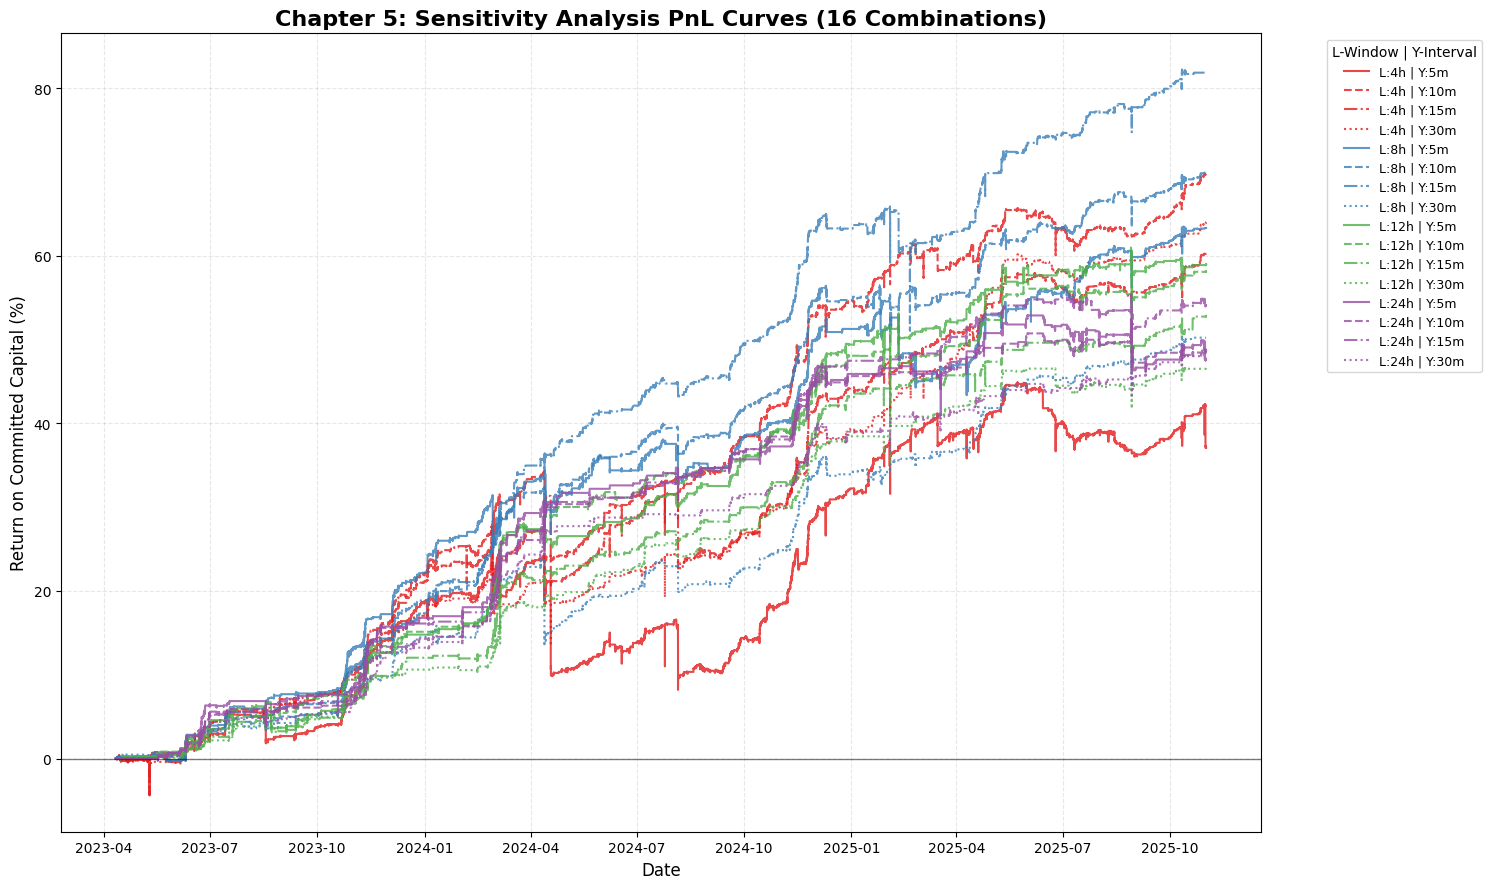

In [9]:
# %%
# ==============================================================================
# VISUALIZATION: SENSITIVITY PNL MATRIX
# ==============================================================================
import matplotlib.pyplot as plt

def plot_sensitivity_curves():
    print("Generating Sensitivity PnL Chart...")
    plt.figure(figsize=(15, 9))
    
    # Define colors for L-frequencies and styles for Y-intervals to keep it organized
    colors = {
        "Fast_4h": "#e41a1c",   # Red
        "Medium_8h": "#377eb8", # Blue
        "Slow_12h": "#4daf4a",  # Green
        "Daily_24h": "#984ea3"  # Purple
    }
    styles = {
        "5m": "-",      # Solid
        "10m": "--",    # Dashed
        "15m": "-.",    # Dash-dot
        "30m": ":"      # Dotted
    }

    found_files = False
    for l_case in Config.L_CASES:
        l_name = l_case['name']
        for y_int in Config.Y_INTERVALS:
            run_id = f"Grid_{l_name}_{y_int}"
            path = os.path.join(Config.RESULTS_DIR_SENS, f"{run_id}.parquet")
            
            if os.path.exists(path):
                found_files = True
                df = pd.read_parquet(path)
                roi = (df['pnl'] / Config.COMMITTED_CAPITAL) * 100
                
                plt.plot(
                    df['time'], roi, 
                    color=colors.get(l_name, "black"), 
                    linestyle=styles.get(y_int, "-"),
                    alpha=0.8,
                    label=f"L:{l_name.split('_')[1]} | Y:{y_int}",
                    linewidth=1.5
                )

    if not found_files:
        print("Error: No sensitivity result files found in directory.")
        return

    plt.axhline(0, color='black', linewidth=1, alpha=0.5)
    plt.title("Chapter 5: Sensitivity Analysis PnL Curves (16 Combinations)", fontsize=16, fontweight='bold')
    plt.ylabel("Return on Committed Capital (%)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    
    # Place legend outside to the right
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, title="L-Window | Y-Interval")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # Save the chart for the thesis
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "Sensitivity_PnL_Matrix.png"), dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    plot_sensitivity_curves()

# corr and # of pairs

⚡ Cache valid! Loading base data...

[START] Corr_0.8 | Corr: 0.8 | Max Pairs: 10
[Corr_0.8] -> 2025-11-01 00:00:00 | CumPnL: 12.16   
Saved Corr_0.8 to disk.

[START] Corr_0.85 | Corr: 0.85 | Max Pairs: 10
[Corr_0.85] -> 2025-11-01 00:00:00 | CumPnL: 10.30   
Saved Corr_0.85 to disk.

[START] Corr_0.9 | Corr: 0.9 | Max Pairs: 10
[Corr_0.9] -> 2025-11-01 00:00:00 | CumPnL: 16.37   
Saved Corr_0.9 to disk.

[START] Corr_0.95 | Corr: 0.95 | Max Pairs: 10
[Corr_0.95] -> 2025-11-01 00:00:00 | CumPnL: 7.63   
Saved Corr_0.95 to disk.

[START] Pairs_5 | Corr: 0.9 | Max Pairs: 5
[Pairs_5] -> 2025-11-01 00:00:00 | CumPnL: 9.44    
Saved Pairs_5 to disk.

[START] Pairs_15 | Corr: 0.9 | Max Pairs: 15
[Pairs_15] -> 2025-11-01 00:00:00 | CumPnL: 20.64   
Saved Pairs_15 to disk.

[START] Pairs_20 | Corr: 0.9 | Max Pairs: 20
[Pairs_20] -> 2025-11-01 00:00:00 | CumPnL: 24.16   
Saved Pairs_20 to disk.

SENSITIVITY ANALYSIS: CORRELATION THRESHOLD (Pairs=10)
                       Return (%)  Max DD (%

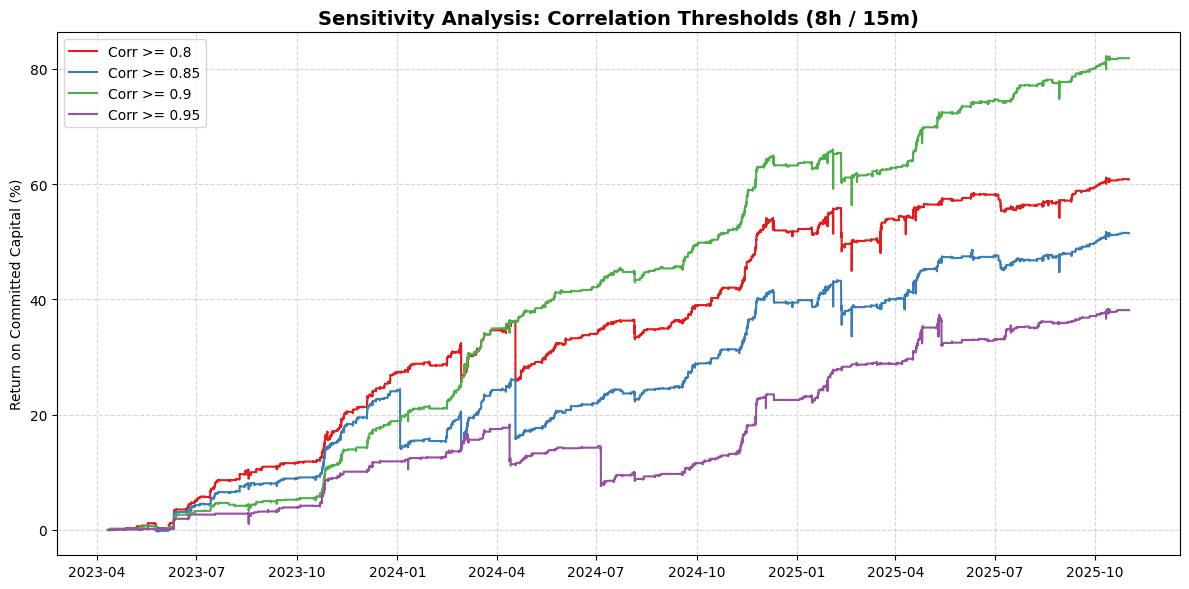

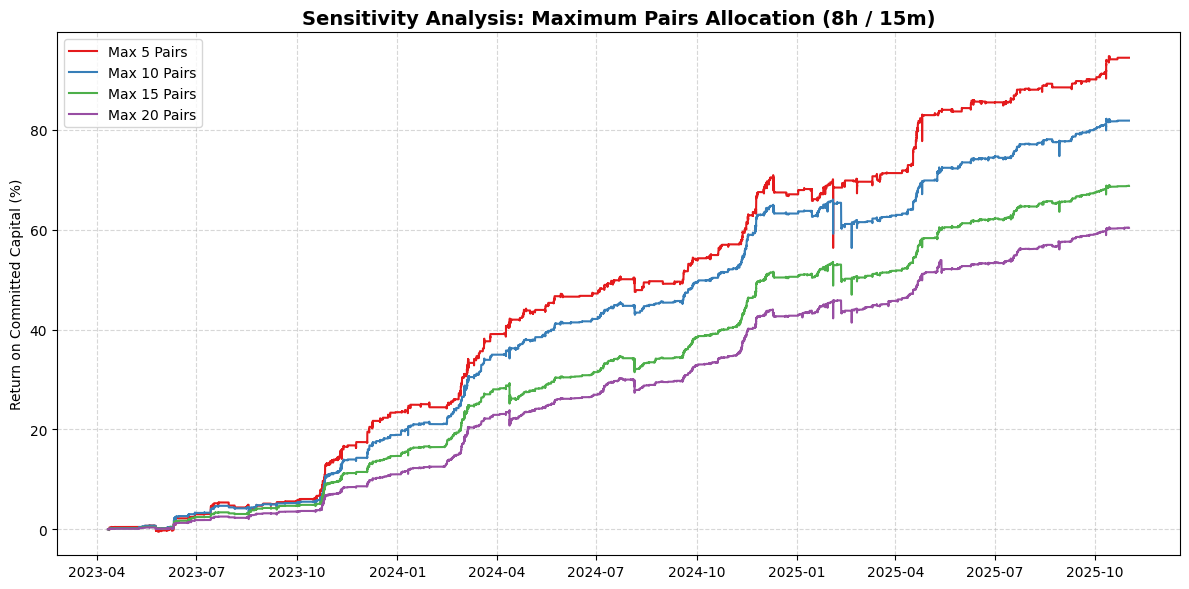

In [ ]:
# %%
# ==============================================================================
# MASTER THESIS: SENSITIVITY ANALYSIS - CORRELATION & MAX PAIRS
# ==============================================================================

import os
import glob
import json
import warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

%matplotlib inline
warnings.filterwarnings('ignore')

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    DATA_PATH = "D:\\MASTER THESIS DATA\\bitmex\\processed_5m_bidask\\"
    FUNDING_PATH = "D:\\MASTER THESIS DATA\\bitmex\\funding_rates\\"
    OUTPUT_DIR = "D:\\MASTER THESIS DATA\\results\\"
    CACHE_DIR = os.path.join(OUTPUT_DIR, "data_cache")
    RESULTS_DIR_PARAMS = os.path.join(OUTPUT_DIR, "run_results_params") 
    
    START_DATE = "2023-01-01"
    END_DATE = "2025-11-01"
    FFILL_LIMIT = 288
    
    # Base Case configuration (The Winner)
    L_FREQ = "8h"
    WINDOW_L = 30
    Y_INTERVAL = "15m"
    WINDOW_Y = 7
    
    TC_BPS = 5.0
    MAX_SPREAD_PCT = 0.05

for d in[Config.OUTPUT_DIR, Config.CACHE_DIR, Config.RESULTS_DIR_PARAMS]:
    os.makedirs(d, exist_ok=True)

# %%
# ==========================================
# 2. DATA HANDLERS
# ==========================================
class FastDataHandler:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df_mid = self.df_bid = self.df_ask = None
        self.meta_file = os.path.join(Config.CACHE_DIR, "meta.json")

    def _is_cache_valid(self):
        if not os.path.exists(self.meta_file): return False
        try:
            with open(self.meta_file, "r") as f: meta = json.load(f)
            return meta.get("START_DATE") == Config.START_DATE and meta.get("END_DATE") == Config.END_DATE
        except: return False

    def load_data(self):
        if self._is_cache_valid():
            print(f"⚡ Cache valid! Loading base data...")
            self.df_mid = pl.read_parquet(os.path.join(Config.CACHE_DIR, "mid.parquet"))
            self.df_bid = pl.read_parquet(os.path.join(Config.CACHE_DIR, "bid.parquet"))
            self.df_ask = pl.read_parquet(os.path.join(Config.CACHE_DIR, "ask.parquet"))
            return

        print(f"Processing raw data from {self.folder_path}...")
        all_files =[f for f in glob.glob(os.path.join(self.folder_path, "**", "*.parquet"), recursive=True) if "data_cache" not in f]
        q = pl.scan_parquet(all_files).with_columns(pl.col("timestamp").cast(pl.Datetime))
        q = q.with_columns([
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("mid_price")).otherwise(None).alias("mid_price"),
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("bid_price")).otherwise(None).alias("bid_price"),
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("ask_price")).otherwise(None).alias("ask_price")
        ])
        
        df_long = q.collect()
        s_dt, e_dt = datetime.strptime(Config.START_DATE, "%Y-%m-%d"), datetime.strptime(Config.END_DATE, "%Y-%m-%d")
        df_long = df_long.filter((pl.col("timestamp") >= s_dt) & (pl.col("timestamp") <= e_dt))
        
        self.df_mid = df_long.pivot(index="timestamp", on="symbol", values="mid_price", aggregate_function="last").sort("timestamp")
        self.df_bid = df_long.pivot(index="timestamp", on="symbol", values="bid_price", aggregate_function="last").sort("timestamp")
        self.df_ask = df_long.pivot(index="timestamp", on="symbol", values="ask_price", aggregate_function="last").sort("timestamp")
        
        grid = pl.datetime_range(self.df_mid["timestamp"].min(), self.df_mid["timestamp"].max(), interval="5m", eager=True).alias("timestamp").to_frame()
        grid = grid.with_columns(pl.col("timestamp").cast(self.df_mid["timestamp"].dtype))
        
        def align(df):
            return grid.join(df, on="timestamp", how="left").with_columns(pl.all().forward_fill(limit=Config.FFILL_LIMIT))

        self.df_mid, self.df_bid, self.df_ask = align(self.df_mid), align(self.df_bid), align(self.df_ask)
        
        self.df_mid.write_parquet(os.path.join(Config.CACHE_DIR, "mid.parquet"))
        self.df_bid.write_parquet(os.path.join(Config.CACHE_DIR, "bid.parquet"))
        self.df_ask.write_parquet(os.path.join(Config.CACHE_DIR, "ask.parquet"))
        with open(self.meta_file, "w") as f: json.dump({"START_DATE": Config.START_DATE, "END_DATE": Config.END_DATE}, f)

    def get_resampled_slices(self, start, end, interval="5m"):
        mask = (self.df_mid["timestamp"] >= start) & (self.df_mid["timestamp"] <= end)
        mid, bid, ask = self.df_mid.filter(mask), self.df_bid.filter(mask), self.df_ask.filter(mask)
        if interval != "5m":
            mid = mid.set_sorted("timestamp").group_by_dynamic("timestamp", every=interval).agg(pl.exclude("timestamp").last())
            bid = bid.set_sorted("timestamp").group_by_dynamic("timestamp", every=interval).agg(pl.exclude("timestamp").last())
            ask = ask.set_sorted("timestamp").group_by_dynamic("timestamp", every=interval).agg(pl.exclude("timestamp").last())
        return mid, bid, ask

class FundingHandler:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df_funding = None
        
    def load_rates(self):
        try:
            q = pl.scan_csv(os.path.join(self.folder_path, "*.csv"))
            self.df_funding = (
                q.with_columns([pl.col("timestamp").str.replace("T", " ").str.replace("Z", "").str.to_datetime(strict=False).dt.replace_time_zone(None)])
                .drop_nulls(subset=["timestamp"]).select(["timestamp", "symbol", "fundingRate"])
                .collect().pivot(index="timestamp", on="symbol", values="fundingRate", aggregate_function="last").sort("timestamp")
            )
        except: print("Funding Load Failed.")
        
    def get_rates_slice(self, start, end):
        if self.df_funding is None: return None
        return self.df_funding.filter((pl.col("timestamp") >= start) & (pl.col("timestamp") <= end))

# %%
# ==========================================
# 3. MATH & ENGINE
# ==========================================
class OUCalibrator:
    @staticmethod
    def fit(spread, dt=1.0):
        if np.isnan(spread).any() or len(spread) < 15: return {'success': False}
        x, y = spread[:-1], spread[1:]
        denom = (len(spread)-1) * np.sum(x*x) - np.sum(x)**2
        if denom == 0: return {'success': False}
        
        b = ((len(spread)-1) * np.sum(x*y) - np.sum(x) * np.sum(y)) / denom
        a = (np.sum(y) - b * np.sum(x)) / (len(spread)-1)
        
        if b >= 0.999 or b <= 0.0: return {'success': False}
        
        theta = -np.log(b) / dt
        sigma = np.std(y - (a + b * x)) * np.sqrt((2 * theta) / (1 - b**2))
        return {'theta': theta, 'sigma': sigma, 'success': True}

class StrategyEngine:
    def __init__(self, dh, fh, corr_thresh, max_pairs, run_id):
        self.dh, self.fh = dh, fh
        self.corr_thresh = corr_thresh
        self.max_pairs = max_pairs
        self.run_id = run_id
        
        self.y_mins = int(Config.Y_INTERVAL.replace("m", ""))
        self.dt_Y = self.y_mins / (24 * 60)
        self.dt_L = int(Config.L_FREQ.replace("h", "")) / 24.0
        
        self.equity_curve =[]

    def get_symbol_root(self, symbol):
        for base in['USDT', 'USDC', 'USD', 'EUR', 'BTC', 'ETH']:
            if symbol.endswith(base): return symbol[:-len(base)]
        return symbol

    def run(self):
        print(f"\n[START] {self.run_id} | Corr: {self.corr_thresh} | Max Pairs: {self.max_pairs}")
        df_L_agg = self.dh.df_mid.set_sorted("timestamp").group_by_dynamic("timestamp", every=Config.L_FREQ).agg(pl.exclude("timestamp").last())
        trend_dates = df_L_agg["timestamp"].to_list()
        
        # Start after maximum lookback (100 days) to keep test period identical to chapter 4
        start_idx = next(i for i, d in enumerate(trend_dates) if d >= trend_dates[0] + timedelta(days=100))
        
        cumulative_pnl = 0.0
        all_syms = [c for c in self.dh.df_mid.columns if c != "timestamp"]
        
        for i in range(start_idx, len(trend_dates)-1):
            curr_t, next_t = trend_dates[i], trend_dates[i+1]
            
            df_L_hist = df_L_agg.filter((pl.col("timestamp") >= curr_t - timedelta(days=Config.WINDOW_L)) & (pl.col("timestamp") <= curr_t))
            df_Y_hist, _, _ = self.dh.get_resampled_slices(curr_t - timedelta(days=Config.WINDOW_Y), curr_t, Config.Y_INTERVAL)
            df_t_mid, df_t_bid, df_t_ask = self.dh.get_resampled_slices(curr_t, next_t, Config.Y_INTERVAL)
            
            if df_t_mid.height < 5: continue

            valid_syms =[s for s in all_syms if df_Y_hist[s].null_count() == 0]
            if len(valid_syms) < 2: continue
            
            corr_mat = df_Y_hist.select(valid_syms).corr().to_numpy()
            cands =[]
            
            for r in range(len(valid_syms)):
                for c in range(r+1, len(valid_syms)):
                    sym_a, sym_b = valid_syms[r], valid_syms[c]
                    if self.get_symbol_root(sym_a) == self.get_symbol_root(sym_b) or corr_mat[r,c] < self.corr_thresh: continue
                    
                    l_vals = np.log(df_L_hist[sym_a].to_numpy()) - np.log(df_L_hist[sym_b].to_numpy())
                    pL = OUCalibrator.fit(l_vals, dt=self.dt_L)
                    if not pL['success']: continue
                    
                    y_vals = np.log(df_Y_hist[sym_a].to_numpy()) - np.log(df_Y_hist[sym_b].to_numpy())
                    pY = OUCalibrator.fit(y_vals, dt=self.dt_Y) 
                    if not pY['success']: continue
                    
                    var_L = (pL['sigma']**2 / (2 * pL['theta'])) * (1 - np.exp(-2 * pL['theta'] * self.dt_L))
                    var_Y = (pY['sigma']**2 / (2 * pY['theta'])) * (1 - np.exp(-2 * pY['theta'] * self.dt_Y))
                    
                    cands.append({
                        'pair': (sym_a, sym_b),
                        'score': var_Y / (var_L + 1e-9),
                        'target': (l_vals[-1] + l_vals[-2]) / 2.0,
                        'eps': np.percentile(np.abs(np.diff(l_vals)), 98)
                    })
            
            cands.sort(key=lambda x: x['score'], reverse=True)
            final_selection, active_roots =[], set()
            
            for cand in cands:
                if len(final_selection) >= self.max_pairs: break
                ra, rb = self.get_symbol_root(cand['pair'][0]), self.get_symbol_root(cand['pair'][1])
                if ra in active_roots or rb in active_roots: continue
                active_roots.add(ra); active_roots.add(rb)
                final_selection.append(cand)
            
            if not final_selection: continue
            
            session_pnl_path = self.trade_session(pd.DataFrame(final_selection), df_t_mid, df_t_bid, df_t_ask, curr_t, next_t)
            
            ts_array = df_t_mid["timestamp"].to_numpy()
            for t_idx in range(len(ts_array)):
                self.equity_curve.append({
                    'time': ts_array[t_idx],
                    'pnl': cumulative_pnl + session_pnl_path[t_idx]
                })
                
            cumulative_pnl += session_pnl_path[-1]
            print(f"[{self.run_id}] -> {next_t} | CumPnL: {cumulative_pnl:.2f}   ", end='\r')
            
        print() 
        return pd.DataFrame(self.equity_curve)

    def trade_session(self, pairs_df, df_mid, df_bid, df_ask, start_time, end_time):
        ts = df_mid["timestamp"].to_numpy()
        master_session_path = np.zeros(len(ts))
        fee_rate = Config.TC_BPS / 10000.0
        
        df_fund = self.fh.get_rates_slice(start_time, end_time) if self.fh else None
        funding_events = {pd.Timestamp(r['timestamp']).value: r for r in df_fund.iter_rows(named=True)} if df_fund is not None else {}

        for _, row in pairs_df.iterrows():
            sym_a, sym_b, target, eps = row['pair'][0], row['pair'][1], row['target'], row['eps']
            
            ma, mb = df_mid[sym_a].to_numpy(), df_mid[sym_b].to_numpy()
            ba, bb = df_bid[sym_a].to_numpy(), df_bid[sym_b].to_numpy()
            aa, ab = df_ask[sym_a].to_numpy(), df_ask[sym_b].to_numpy()
            
            with np.errstate(divide='ignore', invalid='ignore'):
                y_spread = np.log(np.where(ma > 0, ma, np.nan)) - np.log(np.where(mb > 0, mb, np.nan))
            
            curr, realized_pnl, floating_pnl, active_margin = 0, 0.0, 0.0, 0.0
            entry_pa = entry_pb = 0.0
            pair_pnl_path = np.zeros(len(ts))
            
            for t in range(len(ts)):
                v = y_spread[t]
                is_nan = np.isnan(v) or np.isnan(ba[t]) or np.isnan(bb[t])
                
                safe_spread = False
                if not is_nan:
                    safe_spread = ((aa[t] - ba[t]) / ba[t] < Config.MAX_SPREAD_PCT) and ((ab[t] - bb[t]) / bb[t] < Config.MAX_SPREAD_PCT)
                
                signal = curr
                if not is_nan:
                    if curr == 0 and safe_spread:
                        if v > target + eps: signal = -1
                        elif v < target - eps: signal = 1
                    elif curr == -1 and v < target: signal = 0
                    elif curr == 1 and v > target: signal = 0
                if t == len(ts) - 1: signal = 0 
                
                # Funding
                if pd.Timestamp(ts[t]).value in funding_events and curr != 0:
                    f_row = funding_events[pd.Timestamp(ts[t]).value]
                    fpnl = 1.0 * curr * ((f_row.get(sym_b, 0.0) or 0.0) - (f_row.get(sym_a, 0.0) or 0.0))
                    realized_pnl += fpnl; active_margin += fpnl 
                
                # M2M & Liquidation
                if curr != 0 and not is_nan:
                    val_a, val_b = (ba[t], ab[t]) if curr == 1 else (aa[t], bb[t])
                    ret_a = (val_a - entry_pa)/entry_pa if curr == 1 else (entry_pa - val_a)/entry_pa
                    ret_b = (entry_pb - val_b)/entry_pb if curr == 1 else (val_b - entry_pb)/entry_pb
                        
                    floating_pnl = ret_a + ret_b
                    if ret_a <= -0.99 or ret_b <= -0.99:
                        realized_pnl += floating_pnl - (2 * fee_rate)
                        curr, signal, floating_pnl = 0, 0, 0.0
                
                # Execution
                if signal != curr:
                    if curr != 0:
                        exit_pa, exit_pb = (ba[t], ab[t]) if curr == 1 else (aa[t], bb[t])
                        r_a = (exit_pa - entry_pa)/entry_pa if curr == 1 else (entry_pa - exit_pa)/entry_pa
                        r_b = (entry_pb - exit_pb)/entry_pb if curr == 1 else (exit_pb - entry_pb)/entry_pb
                        realized_pnl += (r_a + r_b) - (2 * fee_rate)
                        floating_pnl, active_margin = 0.0, 0.0 
                        
                    if signal != 0:
                        entry_pa, entry_pb = (aa[t], bb[t]) if signal == 1 else (ba[t], ab[t])
                        realized_pnl -= (2 * fee_rate)
                        active_margin = -(2 * fee_rate)
                
                curr = signal
                pair_pnl_path[t] = realized_pnl + floating_pnl

            master_session_path += np.maximum(pair_pnl_path, -2.0)

        return master_session_path

# %%
# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    dh = FastDataHandler(Config.DATA_PATH); dh.load_data()
    fh = FundingHandler(Config.FUNDING_PATH); fh.load_rates()
    
    # Define Parameter Grids
    corr_tests =[0.80, 0.85, 0.90, 0.95]
    pairs_tests = [5, 10, 15, 20]
    
    runs_to_execute =[]
    
    # 1. Test Correlation (Fixed pairs = 10)
    for c in corr_tests:
        runs_to_execute.append({"run_id": f"Corr_{c}", "corr": c, "pairs": 10})
        
    # 2. Test Max Pairs (Fixed corr = 0.90)
    for p in pairs_tests:
        if p == 10: continue # Handled in correlation test (Corr_0.90 is the exact same as Pairs_10)
        runs_to_execute.append({"run_id": f"Pairs_{p}", "corr": 0.90, "pairs": p})

    for r in runs_to_execute:
        save_path = os.path.join(Config.RESULTS_DIR_PARAMS, f"{r['run_id']}.parquet")
        if os.path.exists(save_path):
            print(f"Skipping {r['run_id']} (Already cached).")
            continue
            
        eng = StrategyEngine(dh, fh, r['corr'], r['pairs'], r['run_id'])
        df_res = eng.run()
        if not df_res.empty:
            df_res.to_parquet(save_path)
            print(f"Saved {r['run_id']} to disk.")

# %%
# ==========================================
# 5. ANALYSIS & PLOTTING
# ==========================================
def calc_stats_dynamic_capital(df, max_pairs):
    if df.empty: return None
    # Dynamically scale committed capital based on max pairs allowed (2.0 units per pair)
    capital = max_pairs * 2.0
    
    df['roi_pct'] = (df['pnl'] / capital) * 100
    df['date'] = pd.to_datetime(df['time']).dt.date
    daily_rets = df.groupby('date')['roi_pct'].last().diff().fillna(0)
    
    total_ret = df['roi_pct'].iloc[-1]
    eq = df['pnl'] + capital
    max_dd = ((eq - eq.cummax()) / eq.cummax()).min() * 100
    
    std = daily_rets.std()
    sharpe = (daily_rets.mean() / std) * np.sqrt(365) if std != 0 else 0
    neg_rets = daily_rets[daily_rets < 0]
    down_std = np.sqrt((neg_rets**2).mean()) if len(neg_rets) > 0 else 0
    sortino = (daily_rets.mean() / down_std) * np.sqrt(365) if down_std != 0 else 0
    
    return {"Return (%)": round(total_ret, 2), "Max DD (%)": round(max_dd, 2), "Sharpe": round(sharpe, 2), "Sortino": round(sortino, 2)}

# Process Results
corr_res, pairs_res = [],[]
df_curves_corr, df_curves_pairs = {}, {}

for file in glob.glob(os.path.join(Config.RESULTS_DIR_PARAMS, "*.parquet")):
    run_id = os.path.basename(file).replace(".parquet", "")
    df = pd.read_parquet(file)
    
    if run_id.startswith("Corr_"):
        c_val = float(run_id.replace("Corr_", ""))
        stats = calc_stats_dynamic_capital(df, max_pairs=10)
        corr_res.append({"Correlation Threshold": c_val, **stats})
        df_curves_corr[c_val] = df
        
        # Copy the 0.90 / 10 pairs run to the Pairs results as well
        if c_val == 0.90:
            pairs_res.append({"Max Pairs Allowed": 10, **stats})
            df_curves_pairs[10] = df
            
    elif run_id.startswith("Pairs_"):
        p_val = int(run_id.replace("Pairs_", ""))
        stats = calc_stats_dynamic_capital(df, max_pairs=p_val)
        pairs_res.append({"Max Pairs Allowed": p_val, **stats})
        df_curves_pairs[p_val] = df

# --- TABLES ---
if corr_res:
    df_corr = pd.DataFrame(corr_res).sort_values("Correlation Threshold").set_index("Correlation Threshold")
    print("\n" + "="*60)
    print("SENSITIVITY ANALYSIS: CORRELATION THRESHOLD (Pairs=10)")
    print("="*60)
    print(df_corr.to_string())

if pairs_res:
    df_pairs = pd.DataFrame(pairs_res).sort_values("Max Pairs Allowed").set_index("Max Pairs Allowed")
    print("\n" + "="*60)
    print("SENSITIVITY ANALYSIS: MAXIMUM NUMBER OF PAIRS (Corr=0.90)")
    print("="*60)
    print(df_pairs.to_string())

# --- PLOTS ---
colors =['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

if df_curves_corr:
    plt.figure(figsize=(12, 6))
    for i, c_val in enumerate(sorted(df_curves_corr.keys())):
        df = df_curves_corr[c_val]
        roi = (df['pnl'] / 20.0) * 100
        plt.plot(df['time'], roi, label=f"Corr >= {c_val}", color=colors[i], linewidth=1.5)
    plt.title("Sensitivity Analysis: Correlation Thresholds (8h / 15m)", fontsize=14, fontweight='bold')
    plt.ylabel("Return on Committed Capital (%)")
    plt.grid(True, linestyle='--', alpha=0.5); plt.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "Sensitivity_Correlation_Curves.png"), dpi=300)
    plt.show()

if df_curves_pairs:
    plt.figure(figsize=(12, 6))
    for i, p_val in enumerate(sorted(df_curves_pairs.keys())):
        df = df_curves_pairs[p_val]
        # Dynamically scale the y-axis ROI based on capital allocated
        capital = p_val * 2.0
        roi = (df['pnl'] / capital) * 100
        plt.plot(df['time'], roi, label=f"Max {p_val} Pairs", color=colors[i], linewidth=1.5)
    plt.title("Sensitivity Analysis: Maximum Pairs Allocation (8h / 15m)", fontsize=14, fontweight='bold')
    plt.ylabel("Return on Committed Capital (%)")
    plt.grid(True, linestyle='--', alpha=0.5); plt.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "Sensitivity_MaxPairs_Curves.png"), dpi=300)
    plt.show()